# **Serving Up 📚 Text Data for Our  🍽️ RNN's Consumption**

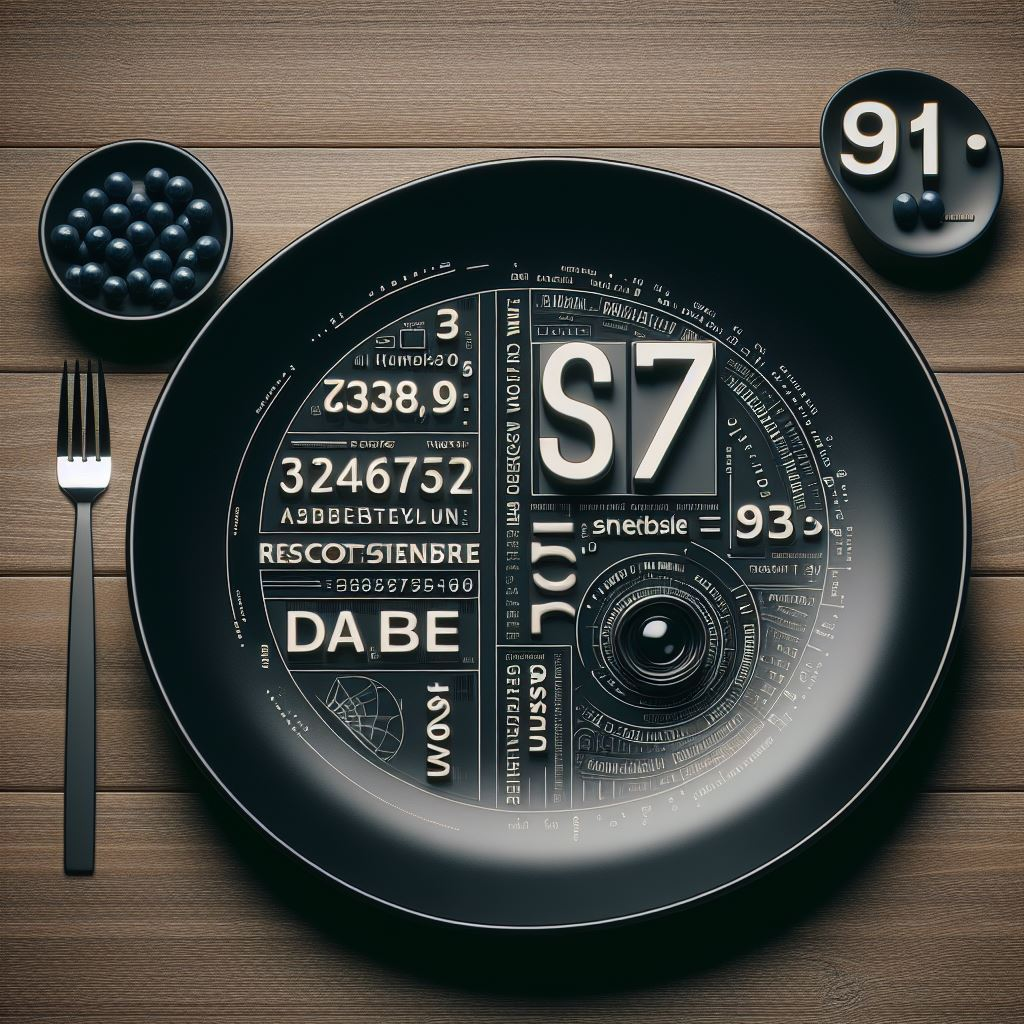


> # **Join Me to Explore How RNNs Understand Text! 📚 Think of RNNs like chefs who mix words to understand language.**

# Let's Prepare Our Main Ingredient: Textual Data! 📚 This ingredient is very flexible, and you can choose it according to your preference. 🎉

# **FIRST STEP**

- In the very first step, I generated random data. Now, I'll convert this data into a format that an RNN can understand and work with. Let's start the journey!

- I'll try my best to explain each step in detail. Let's move forward on our journey!

In [7]:
#  Generated a random data 
import numpy as np

docs = ['sunflower bees',
        'big world',
		'hip hip hurray',
        'walking through the street in the middle of night',
		'i raised a bird name groot',
        'groot is no more',
		'washing bicycle',
        'its a loosing game',
		'happy in delusions',
        'i wish groot will be happy']

In [8]:
from keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(oov_token='<nothing>')

**WORKING OF OUR CODE**

- A `tokenizer` is used to break down text into smaller units called tokens. These tokens can be words, subwords, or characters, depending on the tokenizer's configuration. Tokenization is an important preprocessing step in `natural language processing` tasks, as it allows machines to understand and process `textual data.`

- `from keras.preprocessing.text import Tokenizer`: This line imports the Tokenizer class from the keras.preprocessing.text module. The Tokenizer class is used to tokenize text, which means breaking it down into smaller units like words or subwords.

- `tokenizer = Tokenizer(oov_token='<nothing>'):` If a user enters a word that doesn't exist in our dataset, the oov_token serves as a backup plan and replaces the unknown word with .

- In our cooking adventure, think of the `tokenizer` as a tool that helps chop and organize ingredients 🥒. It breaks down the text into smaller parts, like words or characters 📚, making it easier for our cooking machine (RNN) to understand and work with the recipe! 🍳

In [9]:
tokenizer.fit_on_texts(docs)


The `tokenizer.fit_on_texts(docs)` method is used to update the internal vocabulary of the tokenizer based on the provided text data docs. Here's how it works:

-`Update Vocabulary:` The method processes each document in docs and updates the internal vocabulary of the tokenizer. It assigns a unique integer index to each unique word in the vocabulary.

- `Word Indexing:` Each word in the vocabulary is indexed based on its frequency, with the most frequent word being assigned the index 1, the second most frequent word being assigned the index 2, and so on.

-`Text to Sequence Conversion:` After fitting the tokenizer on the text data, you can use it to convert text into sequences of integers. Each word in the input text is replaced with its corresponding index in the tokenizer's vocabulary.

- Overall, tokenizer.fit_on_texts(docs) prepares the tokenizer to convert text data into a format that can be used by machine learning models, where words are represented as integers.

- Think of `tokenizer.fit_on_texts(docs)` as creating a special dictionary for your recipes. It learns the unique words and their frequencies, so later you can convert any recipe into a list of numbers that your model can understand and work with!

In [10]:
# Lets check the indexing of each word 
tokenizer.word_index

{'<nothing>': 1,
 'groot': 2,
 'hip': 3,
 'the': 4,
 'in': 5,
 'i': 6,
 'a': 7,
 'happy': 8,
 'sunflower': 9,
 'bees': 10,
 'big': 11,
 'world': 12,
 'hurray': 13,
 'walking': 14,
 'through': 15,
 'street': 16,
 'middle': 17,
 'of': 18,
 'night': 19,
 'raised': 20,
 'bird': 21,
 'name': 22,
 'is': 23,
 'no': 24,
 'more': 25,
 'washing': 26,
 'bicycle': 27,
 'its': 28,
 'loosing': 29,
 'game': 30,
 'delusions': 31,
 'wish': 32,
 'will': 33,
 'be': 34}

In [11]:
# The number of unique words in our data lets see in the output cell 
tokenizer.word_counts

OrderedDict([('sunflower', 1),
             ('bees', 1),
             ('big', 1),
             ('world', 1),
             ('hip', 2),
             ('hurray', 1),
             ('walking', 1),
             ('through', 1),
             ('the', 2),
             ('street', 1),
             ('in', 2),
             ('middle', 1),
             ('of', 1),
             ('night', 1),
             ('i', 2),
             ('raised', 1),
             ('a', 2),
             ('bird', 1),
             ('name', 1),
             ('groot', 3),
             ('is', 1),
             ('no', 1),
             ('more', 1),
             ('washing', 1),
             ('bicycle', 1),
             ('its', 1),
             ('loosing', 1),
             ('game', 1),
             ('happy', 2),
             ('delusions', 1),
             ('wish', 1),
             ('will', 1),
             ('be', 1)])

In [12]:
#  Number of rows in our data is 10 
tokenizer.document_count

10

# **SECOND STEP**

In [13]:
sequences = tokenizer.texts_to_sequences(docs)
sequences

[[9, 10],
 [11, 12],
 [3, 3, 13],
 [14, 15, 4, 16, 5, 4, 17, 18, 19],
 [6, 20, 7, 21, 22, 2],
 [2, 23, 24, 25],
 [26, 27],
 [28, 7, 29, 30],
 [8, 5, 31],
 [6, 32, 2, 33, 34, 8]]

**WORKING OF THE CODE**

The code `sequences = tokenizer.texts_to_sequences(docs)` takes a list of text documents docs and converts each document into a sequence of integers using the tokenizer's vocabulary. Here's how it works:

`Text to Sequence Conversion:` For each document in docs, the tokenizer replaces each word with its corresponding integer index in the tokenizer's vocabulary. If a word is not in the vocabulary (i.e., an out-of-vocabulary word), it is either ignored or replaced with a special token (oov_token=' nothing'), 

`Output:` The texts_to_sequences method returns a list of sequences, where each sequence corresponds to a document in docs and contains the integer indices of the words in that document based on the tokenizer's vocabulary.

**EXAMPLE**
Lets Suppose these are the indexed values
> {
    > "apple": 1,
    > "banana": 2,
    > "orange": 3,
    > "grape": 4,
    > "kiwi": 5
}

And we have a list of three text documents:

> - "apple banana"
> - "orange grape kiwi"
> - "banana kiwi orange"

Applying texts_to_sequences to these documents would result in the following sequences:
>
> - "apple banana" --> [1, 2]
> - "orange grape kiwi" --> [3, 4, 5]
> - "banana kiwi orange" --> [2, 5, 3] 

In [17]:
from keras.utils import pad_sequences

# **THIRD STEP**

In [15]:
sequences = pad_sequences(sequences,padding='post')

**WORKING OF THE CODE**

The `pad_sequences function from keras.utils` is used to ensure that all sequences in a list have the same length. Here's how it works:

`Input:` pad_sequences takes a list of sequences as input, where each sequence is a list of integers representing tokens.

`Padding:` It pads the sequences with zeros at the beginning or the end to make them all the same length. This is useful when feeding sequences into a neural network, as they typically require inputs of the same length.

**Parameters:**

- `sequences:` The list of sequences to pad.
- `maxlen:` The maximum length of the sequences. If not provided, the function will use the maximum length of the input sequences.
- `padding:` The padding mode, either 'pre' or 'post'. 'pre' pads at the beginning of the sequences, while 'post' pads at the end.
- `truncating:` The truncation mode, either 'pre' or 'post'. If a sequence is longer than maxlen, it will be truncated accordingly.
- `value:` The value to use for padding.
- `Output:` The function returns a 2D numpy array where each row corresponds to a padded sequence.

**EXAMPLE**
- [0,2,4,3] -->  After Applying Padding   ---> [0,2,4,3]
- [5,2,3]    -->  After Applying Padding  ---> [5,2,3,0]
- [6,1]      -->  After Applying Padding  ---> [6,1,0,0]

now they have the same size 

In [16]:
sequences

array([[ 9, 10,  0,  0,  0,  0,  0,  0,  0],
       [11, 12,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  3, 13,  0,  0,  0,  0,  0,  0],
       [14, 15,  4, 16,  5,  4, 17, 18, 19],
       [ 6, 20,  7, 21, 22,  2,  0,  0,  0],
       [ 2, 23, 24, 25,  0,  0,  0,  0,  0],
       [26, 27,  0,  0,  0,  0,  0,  0,  0],
       [28,  7, 29, 30,  0,  0,  0,  0,  0],
       [ 8,  5, 31,  0,  0,  0,  0,  0,  0],
       [ 6, 32,  2, 33, 34,  8,  0,  0,  0]], dtype=int32)

**THE END :) THANKS FOR READING**